# Bueno bueno

c:\Users\Martin\.conda\envs\env_R11_VC\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\Martin\.conda\envs\env_R11_VC\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


  Q-Learning optimizado — inicio fijo (0, 172)
  GAMMA=0.999 | ALPHA=0.3 | MAX_ITER=1200 | Ep=1000


Entrenando:  10%|██▊                         | 100/1000 [02:09<15:00,  1.00s/it]

Ep  100/1000            Pasos: 1200  Reward:   -256.1  Media100:   -432.1  ε=0.740


Entrenando:  20%|█████▌                      | 200/1000 [04:26<14:03,  1.05s/it]

...

Ep  800/1000  MÍNIMO  Pasos:  604  Reward:   1809.7  Media100:   1780.7  ε=0.090


Entrenando:  90%|█████████████████████████▏  | 900/1000 [14:23<00:48,  2.05it/s]

Ep  900/1000  MÍNIMO  Pasos:  579  Reward:   1819.3  Media100:   1816.4  ε=0.067


Entrenando: 100%|███████████████████████████| 1000/1000 [15:13<00:00,  1.09it/s]


Ep 1000/1000  MÍNIMO  Pasos:  548  Reward:   1833.5  Media100:   1824.4  ε=0.050

Entrenamiento terminado
Mejor reward acumulado: 1833.5  (episodio 1000)
Mínimo en episodio 1000 con 548 pasos


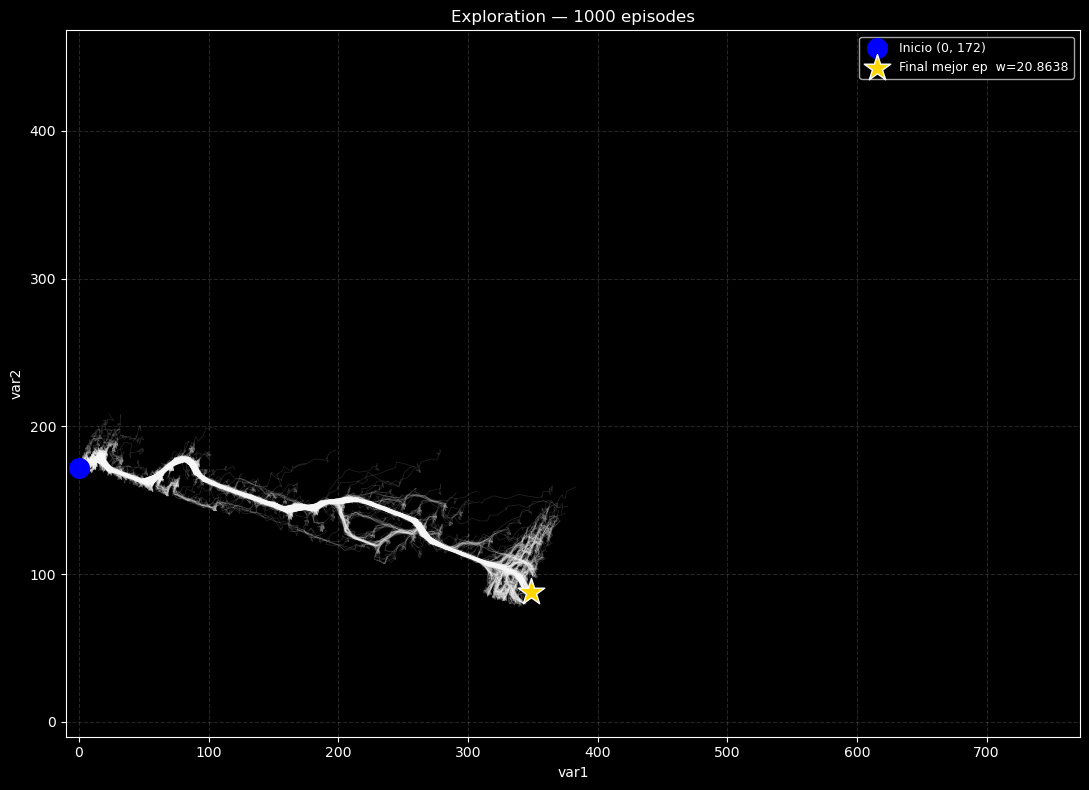

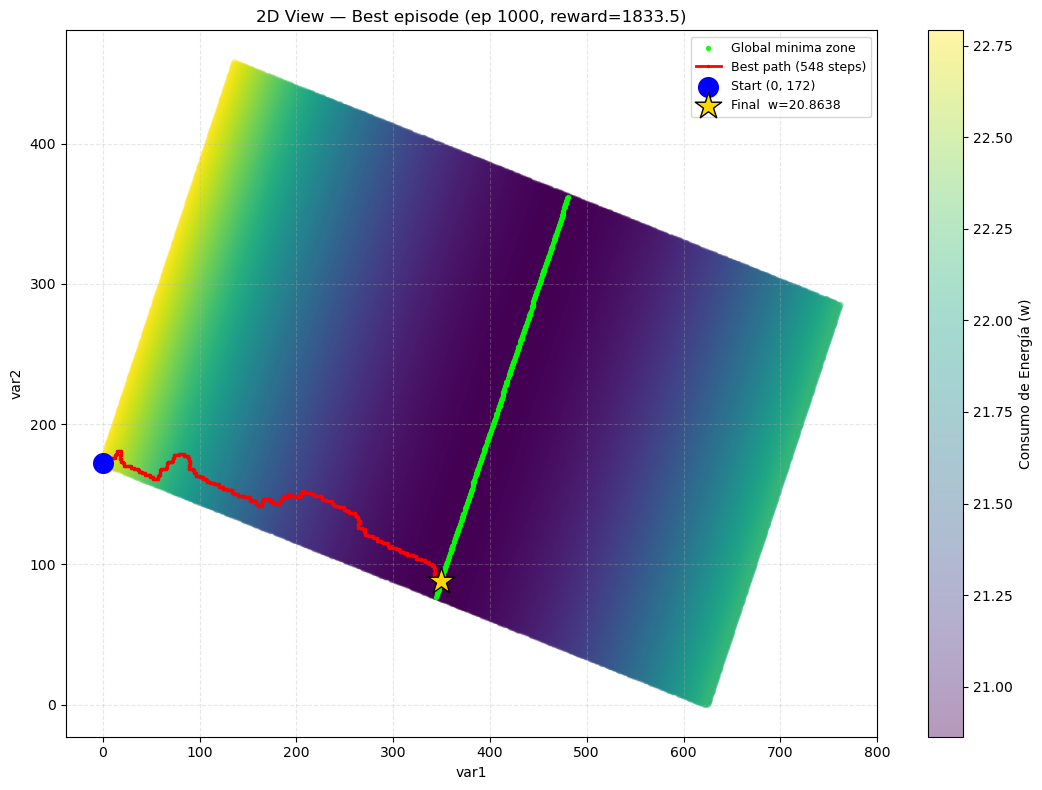

C:\Users\Martin\AppData\Local\Temp\ipykernel_26180\2774498666.py:221: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('../../Graficos/mejor_ruta_3d.png', dpi=120, bbox_inches='tight')
c:\Users\Martin\.conda\envs\env_R11_VC\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


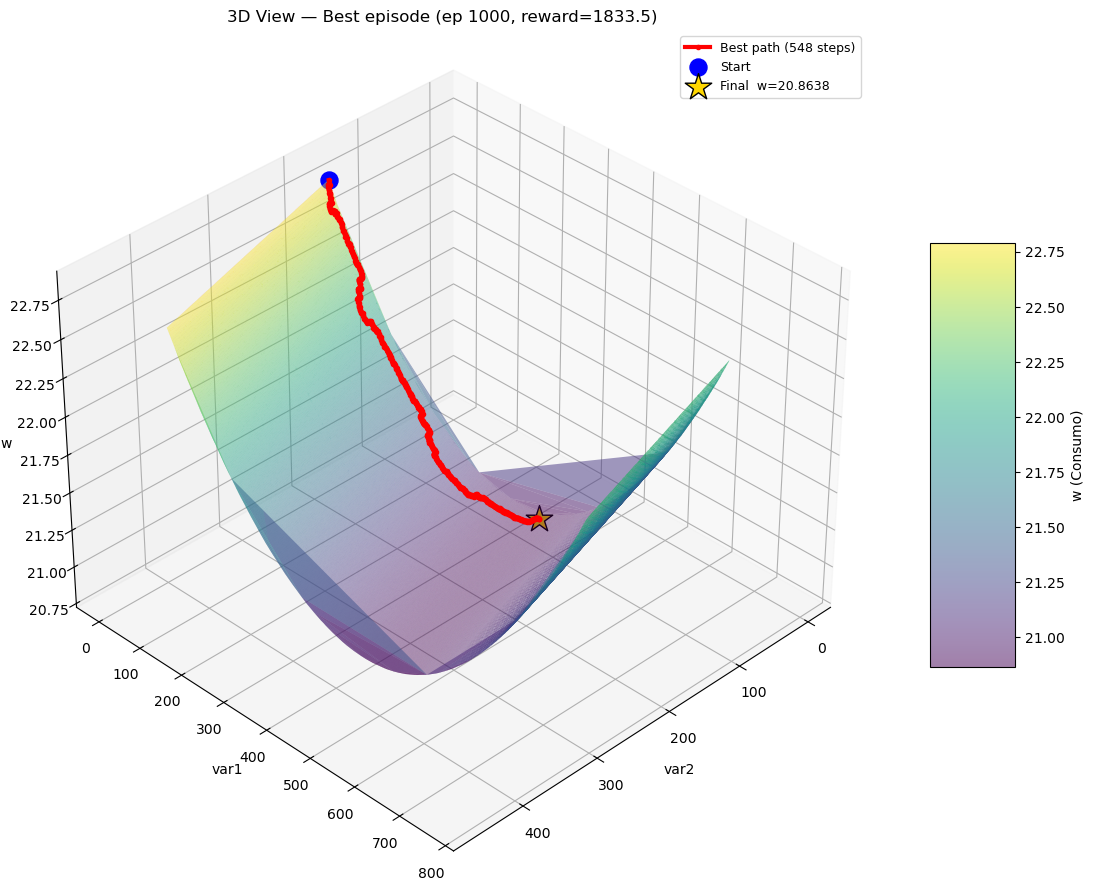

In [2]:

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from env_v1 import motorEnv
from tqdm import tqdm

#  Entorno 
env = motorEnv()

#  Pre-extraemos arrays numpy una sola vez (evita pandas iloc en el loop) 
VAR1 = env.rot['var1'].to_numpy()   
VAR2 = env.rot['var2'].to_numpy()
W    = env.rot['w'].to_numpy()

# Hiperparámetros 
EPISODIOS     = 1000
MAX_ITER      = 1200
ALPHA         = 0.3
GAMMA         = 0.999
EPSILON       = 1.0
EPSILON_MIN   = 0.02
EPSILON_DECAY = 0.9970

# Q-Table 
q_table = np.zeros((env.num_states, env.action_space.n))

historial_recompensas = []
historial_pasos       = []
mejor_recompensa      = -np.inf
mejor_pasos_al_min    = None
episodio_exito        = None

# Solo guardamos el path del MEJOR episodio (no todos — evita crash de memoria)
mejor_camino_v1 = []
mejor_camino_v2 = []
mejor_camino_w  = []
mejor_ep_num    = 0

# Para la exploración: solo guardamos inicio y fin de cada episodio (ligero)
explorar_inicio_v1, explorar_inicio_v2 = [], []
explorar_fin_v1,    explorar_fin_v2    = [], []
# Y una muestra de puntos intermedios (cada N pasos) para dibujar trayectorias
SAMPLE_CADA = 20   # guardamos 1 de cada 20 pasos → ~60 pts/episodio en vez de 1200
explorar_tray_v1 = []
explorar_tray_v2 = []

print("=" * 65)
print("  Q-Learning optimizado — inicio fijo (0, 172)")
print(f"  GAMMA={GAMMA} | ALPHA={ALPHA} | MAX_ITER={MAX_ITER} | Ep={EPISODIOS}")
print("=" * 65)

for episodio in tqdm(range(EPISODIOS), desc="Entrenando", ncols=80):
    estado = env.reset()

    recompensa_acumulada = 0.0
    pasos_dados          = 0
    llego_al_minimo      = False

    # Para el mejor episodio (solo si mejora el reward)
    ep_v1 = [VAR1[estado]]
    ep_v2 = [VAR2[estado]]
    ep_w  = [W[estado]]

    # Trayectoria submuestreada para el gráfico de exploración
    tray_v1 = [VAR1[estado]]
    tray_v2 = [VAR2[estado]]

    for paso in range(MAX_ITER):
        pasos_dados += 1

        if np.random.uniform(0, 1) < EPSILON:
            accion = env.action_space.sample()
        else:
            accion = np.argmax(q_table[estado])

        siguiente_estado, recompensa, done, _ = env.step(accion)

        if paso == MAX_ITER - 1 and not done:
            recompensa -= 20.0
            done = True

        mejor_proxima = np.argmax(q_table[siguiente_estado])
        q_table[estado, accion] += ALPHA * (
            recompensa
            + GAMMA * q_table[siguiente_estado, mejor_proxima]
            - q_table[estado, accion]
        )

        estado = siguiente_estado

        # Usamos arrays numpy (O(1)) en vez de pandas iloc (lento)
        ep_v1.append(VAR1[estado])
        ep_v2.append(VAR2[estado])
        ep_w.append(W[estado])

        # Submuestreo para exploración
        if paso % SAMPLE_CADA == 0:
            tray_v1.append(VAR1[estado])
            tray_v2.append(VAR2[estado])

        recompensa_acumulada += recompensa

        if done:
            if W[estado] == env.w_min:
                llego_al_minimo = True
                if mejor_pasos_al_min is None or pasos_dados < mejor_pasos_al_min:
                    mejor_pasos_al_min = pasos_dados
                    episodio_exito     = episodio + 1
            break

    # Guardamos trayectoria submuestreada (ligera)
    explorar_tray_v1.append(tray_v1)
    explorar_tray_v2.append(tray_v2)

    # Solo actualizamos el mejor camino completo si mejora el reward
    if recompensa_acumulada > mejor_recompensa:
        mejor_recompensa = recompensa_acumulada
        mejor_camino_v1  = ep_v1[:]
        mejor_camino_v2  = ep_v2[:]
        mejor_camino_w   = ep_w[:]
        mejor_ep_num     = episodio + 1

    EPSILON = max(EPSILON_MIN, EPSILON * EPSILON_DECAY)
    historial_recompensas.append(recompensa_acumulada)
    historial_pasos.append(pasos_dados)

    if (episodio + 1) % 100 == 0:
        media = np.mean(historial_recompensas[-100:])
        exito = "MÍNIMO" if llego_al_minimo else "        "
        tqdm.write(f"Ep {episodio+1:4d}/{EPISODIOS}  {exito}  "
                   f"Pasos: {pasos_dados:4d}  "
                   f"Reward: {recompensa_acumulada:8.1f}  "
                   f"Media100: {media:8.1f}  "
                   f"ε={EPSILON:.3f}")

print("\n" + "=" * 65)
print("Entrenamiento terminado")
print(f"Mejor reward acumulado: {mejor_recompensa:.1f}  (episodio {mejor_ep_num})")
if mejor_pasos_al_min is not None:
    print(f"Mínimo en episodio {episodio_exito} con {mejor_pasos_al_min} pasos")
else:
    print("No alcanzó el mínimo")
print("=" * 65)

# Variables compartidas por todos los gráficos
w_final    = mejor_camino_w[-1]
pasos_best = len(mejor_camino_v1) - 1
min_rows   = env.rot[env.rot['w'] == env.w_min]

# GRÁFICO 1 — Exploración (fondo negro, trayectorias submuestreadas)

fig1, ax1 = plt.subplots(figsize=(11, 8))
fig1.patch.set_facecolor('black')
ax1.set_facecolor('black')

for v1s, v2s in zip(explorar_tray_v1, explorar_tray_v2):
    ax1.plot(v1s, v2s, color='white', linewidth=0.5, alpha=0.15)

ax1.scatter(VAR1[0], VAR2[0],
            color='blue', s=200, zorder=6, label='Inicio (0, 172)')
ax1.scatter(mejor_camino_v1[-1], mejor_camino_v2[-1],
            color='gold', marker='*', s=400, edgecolors='white', zorder=6,
            label=f'Final mejor ep  w={w_final:.4f}')
ax1.set_xlim(env.rot['var1'].min()-10, env.rot['var1'].max()+10)
ax1.set_ylim(env.rot['var2'].min()-10, env.rot['var2'].max()+10)
ax1.set_xlabel('var1', color='white'); ax1.set_ylabel('var2', color='white')
ax1.tick_params(colors='white')
for spine in ax1.spines.values(): spine.set_edgecolor('white')
ax1.legend(fontsize=9, facecolor='black', labelcolor='white')
ax1.set_title(f'Exploration — {EPISODIOS} episodes', color='white')
ax1.grid(True, linestyle='--', alpha=0.15, color='white')
plt.tight_layout()
plt.savefig('../../Graficos/exploracion.png', dpi=120, bbox_inches='tight', facecolor='black')
plt.show()

# GRÁFICO 2 — Malla 2D del mejor episodio

fig2, ax2 = plt.subplots(figsize=(11, 8))
sc = ax2.scatter(env.rot['var1'], env.rot['var2'],
                 c=env.rot['w'], cmap='viridis', alpha=0.4, s=15, zorder=1)
plt.colorbar(sc, label='Consumo de Energía (w)', ax=ax2)
ax2.scatter(min_rows['var1'], min_rows['var2'],
            color='lime', s=8, alpha=0.9, zorder=3, label='Global minima zone')
ax2.plot(mejor_camino_v1, mejor_camino_v2, color='red', linewidth=2,
         marker='.', markersize=3, zorder=4,
         label=f'Best path ({pasos_best} steps)')
ax2.scatter(mejor_camino_v1[0], mejor_camino_v2[0],
            color='blue', s=200, zorder=5, label='Start (0, 172)')
ax2.scatter(mejor_camino_v1[-1], mejor_camino_v2[-1],
            color='gold', marker='*', s=400, edgecolors='black', zorder=5,
            label=f'Final  w={w_final:.4f}')
ax2.set_xlabel('var1'); ax2.set_ylabel('var2')
ax2.set_title(f'2D View — Best episode (ep {mejor_ep_num}, reward={mejor_recompensa:.1f})')
ax2.legend(fontsize=9); ax2.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../../Graficos/mejor_ruta_2d.png', dpi=120, bbox_inches='tight')
plt.show()

# GRÁFICO 3 — Malla 3D del mejor episodio

fig3 = plt.figure(figsize=(13, 9))
ax3  = fig3.add_subplot(111, projection='3d')
malla = ax3.plot_trisurf(env.rot['var2'], env.rot['var1'], env.rot['w'],
                          cmap='viridis', alpha=0.5, edgecolor='none')
fig3.colorbar(malla, ax=ax3, shrink=0.5, aspect=5, label='w (Consumo)')
ax3.plot(mejor_camino_v2, mejor_camino_v1, mejor_camino_w,
         color='red', linewidth=3, marker='o', markersize=3,
         label=f'Best path ({pasos_best} steps)', zorder=5)
ax3.scatter(mejor_camino_v2[0],  mejor_camino_v1[0],  mejor_camino_w[0],
            color='blue', s=150, zorder=6, label='Start')
ax3.scatter(mejor_camino_v2[-1], mejor_camino_v1[-1], mejor_camino_w[-1],
            color='gold', marker='*', s=400, edgecolors='black',
            zorder=6, label=f'Final  w={w_final:.4f}')
ax3.set_xlabel('var2'); ax3.set_ylabel('var1'); ax3.set_zlabel('w')
ax3.set_title(f'3D View — Best episode (ep {mejor_ep_num}, reward={mejor_recompensa:.1f})')
ax3.legend(fontsize=9); ax3.view_init(elev=35, azim=45)
plt.tight_layout()
plt.savefig('../../Graficos/mejor_ruta_3d.png', dpi=120, bbox_inches='tight')
plt.show()


In [3]:
np.save("../../Modelos/q_tableV1.npy", q_table)
print("Q-Table guardada en q_tableV1.npy")

Q-Table guardada en q_tableV1.npy
